# Importación de librerías

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# Carga de archivos (.txt) y etiquetado

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# --- CONFIGURACIÓN DE RUTAS ---
bueno_dir = '/content/drive/MyDrive/Colab Notebooks/BUENO-PLUS'
malo_dir = '/content/drive/MyDrive/Colab Notebooks/MALO-PLUS'

X_features = []
y_labels = []

def cargar_datos_tiempo_real(ruta_carpeta, etiqueta):
    conteo_archivos = 0
    conteo_filas = 0
    for archivo in os.listdir(ruta_carpeta):
        if archivo.endswith(".txt"):
            ruta_completa = os.path.join(ruta_carpeta, archivo)
            try:
                # Se cargan archivos de 14 columnas (limpiados previamente)
                df = pd.read_csv(ruta_completa, sep=' ', decimal=',', header=0)
                df = df.apply(pd.to_numeric, errors='coerce').dropna()

                # FILTRO DE FASE: Se filtran las filas donde Aire/Muestra es 1 (Muestra)
                # En el archivo procesado, la fase se encuentra en la última columna (índice 13)
                df_muestra = df[df.iloc[:, 13] == 1]

                # Se extraen las 13 columnas de sensores de gas (índices 0 al 12)
                for row in df_muestra.values:
                    X_features.append(row[:13])
                    y_labels.append(etiqueta)
                    conteo_filas += 1
                conteo_archivos += 1
            except Exception as e:
                print(f"Error en {archivo}: {e}")

    print(f"Carpeta {os.path.basename(ruta_carpeta)}: {conteo_archivos} archivos, {conteo_filas} filas de muestra.")

# Cargar datos
n_buenos = cargar_datos_tiempo_real(bueno_dir, 1) # Clase Positiva
n_malos = cargar_datos_tiempo_real(malo_dir, 0)  # Clase Negativa

X = np.array(X_features)
y = np.array(y_labels)

print(f"Finalizado: {n_buenos} archivos BUENOS y {n_malos} archivos MALOS cargados.")
print(f"Forma de la matriz X: {X.shape}")

Carpeta BUENO-PLUS: 620 archivos, 61000 filas de muestra.
Carpeta MALO-PLUS: 820 archivos, 82000 filas de muestra.
Finalizado: None archivos BUENOS y None archivos MALOS cargados.
Forma de la matriz X: (143000, 13)


# División del Dataset (Train, Val, Test) y Escalado

In [4]:
# Primera división: Se separa el 15% para el TEST FINAL
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Segunda división: Del resto (85%), se separa un ~18% para obtener un 15% del total para VALIDACIÓN
# (0.85 * 0.176 ≈ 0.15)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

# Se realiza el escalado estándar (Z-score)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Muestras totales: {len(X)}")
print(f"Entrenamiento: {len(X_train_scaled)} (70%)")
print(f"Validación:    {len(X_val_scaled)} (15%)")
print(f"Test Final:    {len(X_test_scaled)} (15%)")

Muestras totales: 143000
Entrenamiento: 100157 (70%)
Validación:    21393 (15%)
Test Final:    21450 (15%)


# Definición y Entrenamiento de la ANN

In [5]:
# Se define el modelo
model = Sequential([
    Dense(16, activation='relu', input_shape=(13,)),
    Dropout(0.2), # Se aumenta un poco el dropout para evitar overfitting
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Se establece una parada temprana monitoreando la pérdida de VALIDACIÓN
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Se entrena el modelo
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_scaled, y_val), # Se utiliza el conjunto de validación explícito
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
3130/3130 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.7844 - loss: 0.4031 - val_accuracy: 0.9110 - val_loss: 0.1996
Epoch 2/100
3130/3130 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9013 - loss: 0.2116 - val_accuracy: 0.9228 - val_loss: 0.1618
Epoch 3/100
3130/3130 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9152 - loss: 0.1763 - val_accuracy: 0.9300 - val_loss: 0.1468
Epoch 4/100
3130/3130 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9206 - loss: 0.1641 - val_accuracy: 0.9325 - val_loss: 0.1380
Epoch 5/100
3130/3130 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9242 - loss: 0.1567 - val_accuracy: 0.9322 - val_loss: 0.1329
Epoch 6/100
3130/3130 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9251 - loss: 0.1539 - val_accuracy: 0.9340 - val_loss: 0.1300
Epoch 7/100
3130/3130 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9272 - loss: 0.1508 - val_accuracy: 0.9382 - val_loss: 0.1254
Epoch 8/100
3130/3130 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9260 - los

# Evaluación y Resultados

671/671 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9480 - loss: 0.1019

>> PRECISIÓN FINAL EN EL TEST: 94.67%


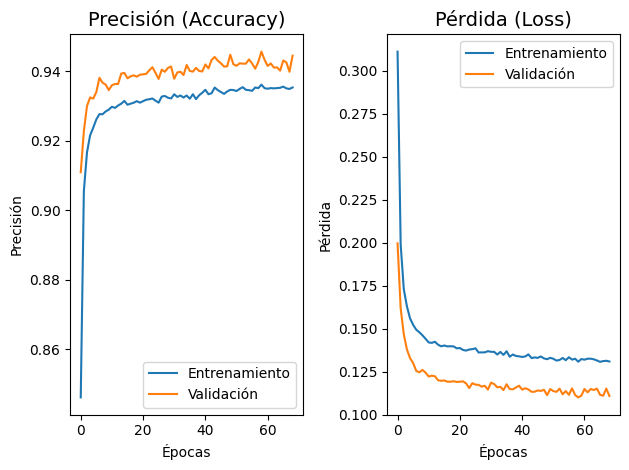

In [6]:
# Se evalúa el modelo con el conjunto de Test
loss, acc = model.evaluate(X_test_scaled, y_test)
print(f"\n>> PRECISIÓN FINAL EN EL TEST: {acc*100:.2f}%")

# Se genera la gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión (Accuracy)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Se genera la gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

671/671 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


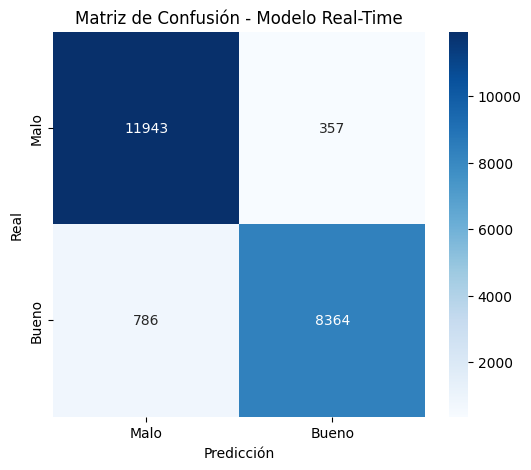

In [7]:
# Se realizan predicciones en el conjunto de prueba
y_pred = (model.predict(X_test_scaled) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Malo', 'Bueno'], yticklabels=['Malo', 'Bueno'])
plt.title('Matriz de Confusión - Modelo Real-Time')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.show()

# Exportar y guardar el modelo

In [8]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_path = '/content/modelo_hachis2-plus.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"\nProceso finalizado. Descarga el archivo: {tflite_path}")

Saved artifact at '/tmp/tmpo4c4mgqi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 13), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138845044995856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138844772713296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138844772713872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138844772715408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138844772715024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138844772715792: TensorSpec(shape=(), dtype=tf.resource, name=None)

Proceso finalizado. Descarga el archivo: /content/modelo_hachis2-plus.tflite


In [9]:
print("Medias para Flutter:", list(scaler.mean_))
print("Desviaciones para Flutter:", list(np.sqrt(scaler.var_)))

Medias para Flutter: [np.float64(1158.5039598116634), np.float64(31488.57528385497), np.float64(2.7238270226027326), np.float64(2472.2227223215277), np.float64(2615.2360985633577), np.float64(356.03156996283), np.float64(334.252491672405), np.float64(78.50346622630231), np.float64(5.397683660595528), np.float64(1.134394810355474), np.float64(438.0369713681038), np.float64(2.2109649987609443), np.float64(416441.2010026929)]
Desviaciones para Flutter: [np.float64(356.8687261603848), np.float64(2089.1240341920043), np.float64(1.0351215447236968), np.float64(10790.125345856011), np.float64(10535.918586990798), np.float64(159.45193910139668), np.float64(183.00433158469443), np.float64(24.965006050256935), np.float64(0.1609831021859847), np.float64(3.90625069189541), np.float64(36.99885361740059), np.float64(1.0246196778845005), np.float64(113934.30515847425)]
